In [683]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [684]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [685]:
df=pd.read_csv('C:\\Users\\user\\Desktop\\ml project\\food_time.csv')
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [686]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [687]:
df.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36


In [688]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
dtype: object

In [689]:
df.size

911860

In [690]:
df.shape

(45593, 20)

In [691]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)'],
      dtype='object')

In [692]:
df.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [693]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

## missing value handle

In [694]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

## detecting dublicates

In [695]:
df.duplicated().sum()

np.int64(0)

## univariate anlysis

In [696]:
cat_cols = df.select_dtypes(include=['object']).columns

In [697]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols

Index(['Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Vehicle_condition'],
      dtype='object')

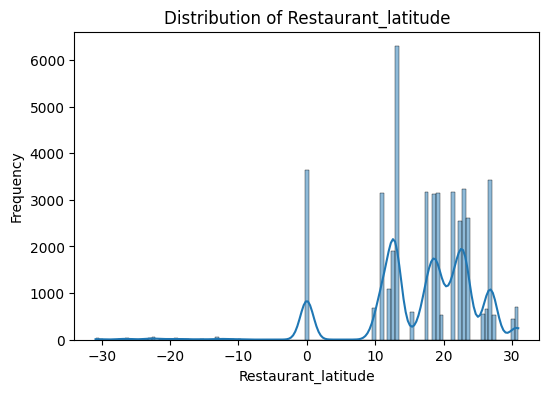

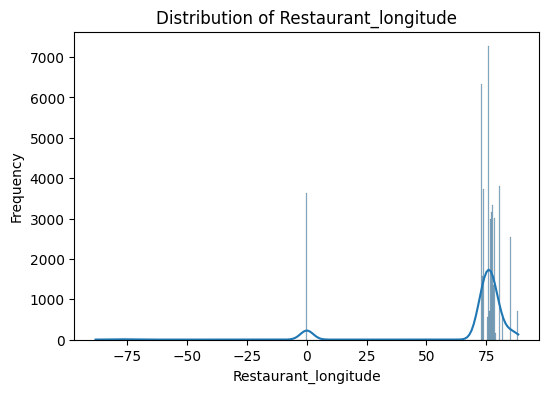

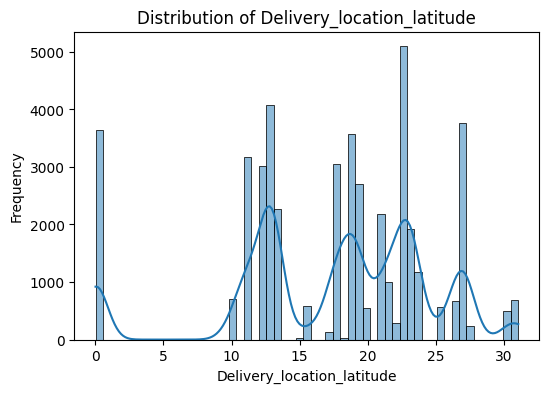

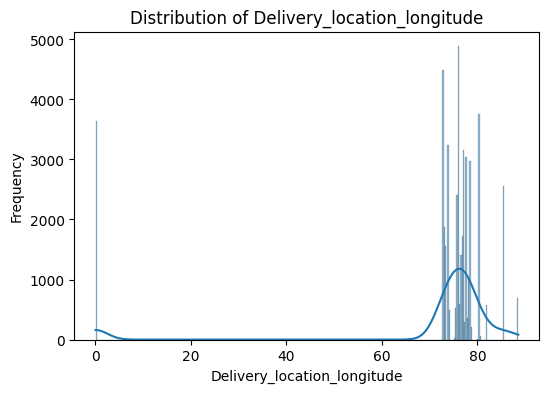

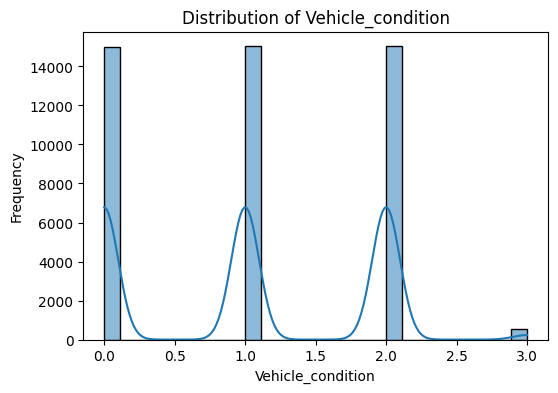

In [698]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## heatmap

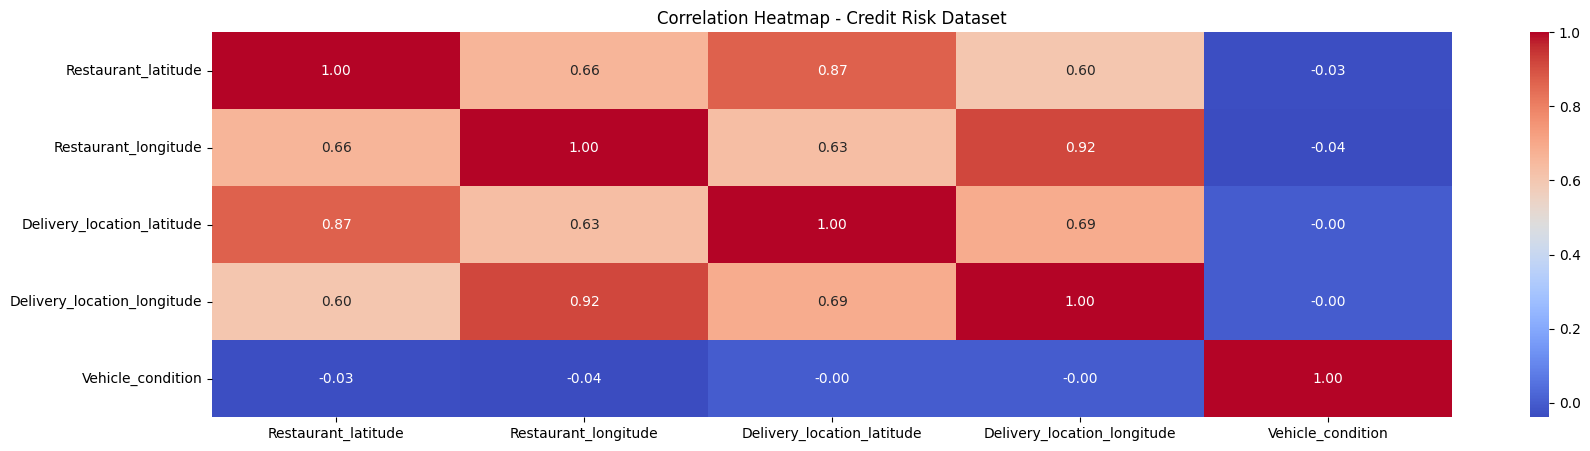

In [699]:
plt.figure(figsize=(20,5))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Credit Risk Dataset')
plt.show()

## bivariate anlysis

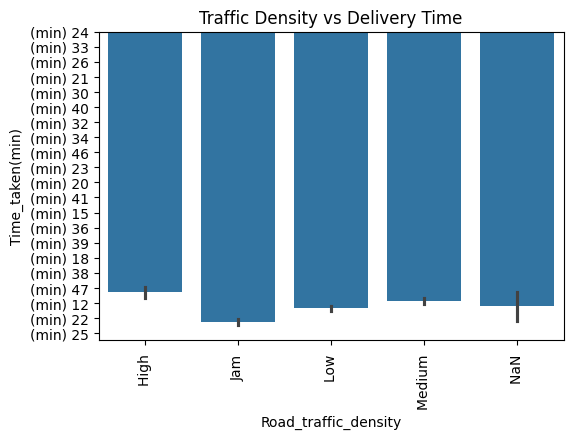

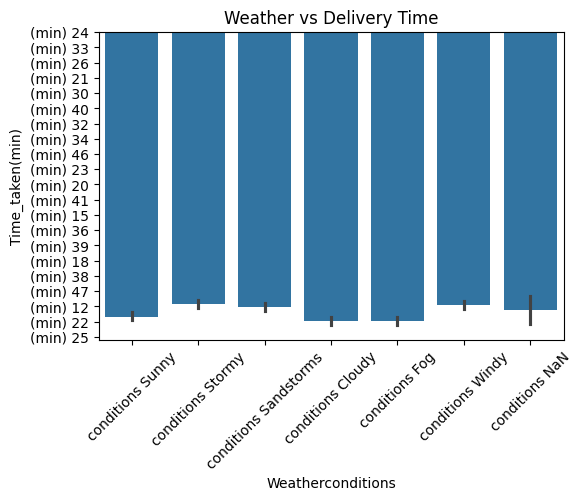

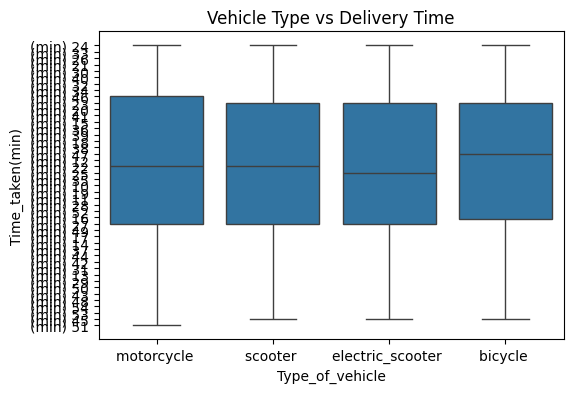

In [700]:
plt.figure(figsize=(6,4))
sns.barplot(x='Road_traffic_density', y='Time_taken(min)', data=df)
plt.title("Traffic Density vs Delivery Time")
plt.xticks(rotation=90)
plt.show()
plt.figure(figsize=(6,4))
sns.barplot(x='Weatherconditions', y='Time_taken(min)', data=df)
plt.xticks(rotation=45)
plt.title("Weather vs Delivery Time")
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(x='Type_of_vehicle', y='Time_taken(min)', data=df)
plt.title("Vehicle Type vs Delivery Time")
plt.show()

## outliers detection


Outliers in Restaurant_latitude: 431
Lower bound: -1.7590344999999967, Upper bound: 37.420481499999994


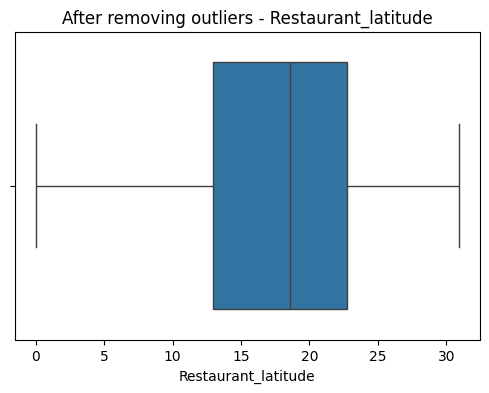


Outliers in Restaurant_longitude: 4463
Lower bound: 65.85766899999999, Upper bound: 85.35797300000002


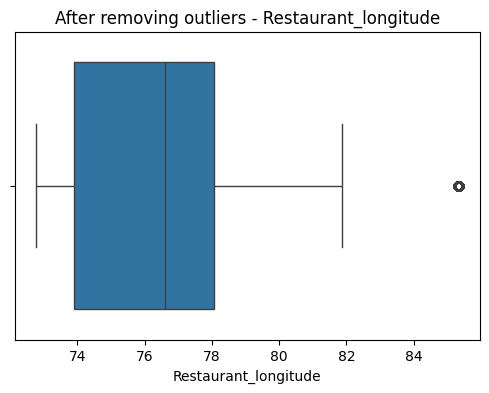


Outliers in Delivery_location_latitude: 0
Lower bound: -1.5792979999999996, Upper bound: 37.459694


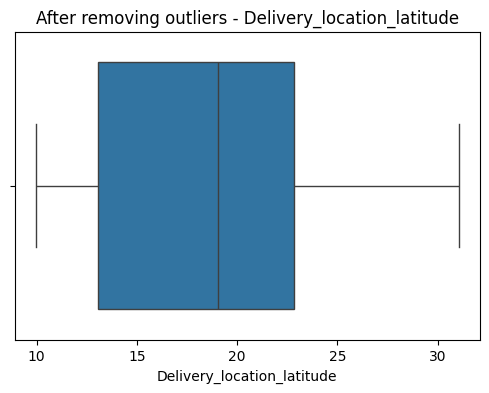


Outliers in Delivery_location_longitude: 2389
Lower bound: 67.61050674999998, Upper bound: 84.45842074999999


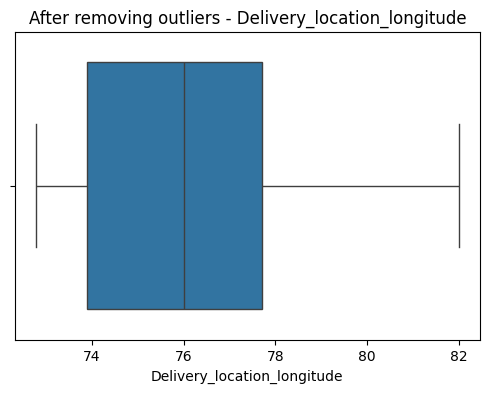


Outliers in Vehicle_condition: 0
Lower bound: -3.0, Upper bound: 5.0


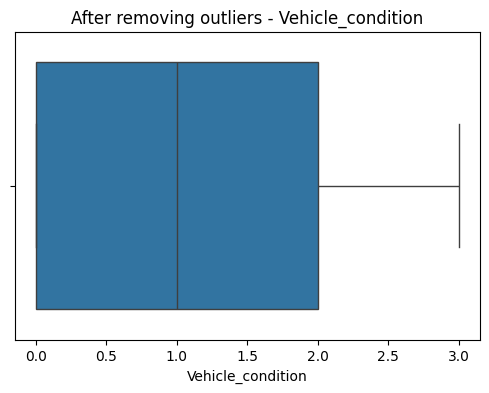


New Shape after outlier removal: (38310, 20)


In [701]:
def handle_outliers_iqr(data, column):
    """Remove outliers using the IQR method"""
    Q1 = data[column].quantile(0.25)#17
    Q3 = data[column].quantile(0.75)#209
    IQR = Q3 - Q1#192
    lower = Q1 - 1.5 * IQR# 
    upper = Q3 + 1.5 * IQR#
    
    print(f"\nOutliers in {column}: {(data[column] < lower).sum() + (data[column] > upper).sum()}")
    print(f"Lower bound: {lower}, Upper bound: {upper}")
    
    # # Visualize before removal
    # plt.figure(figsize=(6,4))
    # sns.boxplot(x=data[column])
    # plt.title(f"Before removing outliers - {column}")
    # plt.show()
    
    # Remove outliers
    data = data[(data[column] >= lower) & (data[column] <= upper)]
    
    # Visualize after removal
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data[column])
    plt.title(f"After removing outliers - {column}")
    plt.show()
    
    return data

# Apply to numeric columns
numeric_col=df.select_dtypes(include=['Int64','Float64']).columns
for col in numeric_col:
    df = handle_outliers_iqr(df, col)

print("\nNew Shape after outlier removal:", df.shape)

In [702]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [703]:
df.replace("NaN ", pd.NA, inplace=True)
df.replace("NaN", pd.NA, inplace=True)

In [704]:
df.dropna(inplace=True)

In [705]:
df.drop(['ID','Delivery_person_ID'], axis=1, inplace=True)

In [706]:
df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors="coerce")

df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")

## feature engineering

In [707]:
df['distance'] = np.sqrt(
(df['Restaurant_latitude'] - df['Delivery_location_latitude'])**2 +
(df['Restaurant_longitude'] - df['Delivery_location_longitude'])**2
)

In [708]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["order_day"] = df["Order_Date"].dt.day
df["order_month"] = df["Order_Date"].dt.month
df["order_weekday"] = df["Order_Date"].dt.weekday

In [709]:
df.drop("Order_Date", axis=1, inplace=True)

In [710]:
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")

df["order_hour"] = df["Time_Orderd"].dt.hour
df["picked_hour"] = df["Time_Order_picked"].dt.hour

In [711]:
df.drop(["Time_Orderd","Time_Order_picked"], axis=1, inplace=True)

## encoding

In [712]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = ['Weatherconditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']

for col in cat_cols:
    
    df[col] = df[col].astype(str)   # convert to string
    
    df[col] = le.fit_transform(df[col])

In [717]:
# remove (min) text and keep only number
df["Time_taken(min)"] = df["Time_taken(min)"].astype(str).str.extract('(\d+)')

# convert to integer
df["Time_taken(min)"] = df["Time_taken(min)"].astype(int)

In [718]:
X = df.drop("Time_taken(min)", axis=1)
y = df["Time_taken(min)"]

In [719]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [720]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.8308906614940733
MAE: 3.054624839216807
